## SMET Output Analysis

## Imports

In [3]:
import snowpat.pysmet as smet
import pandas as pd
import numpy as np
import xarray as xr

file = smet.read('S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.smet')
data_pandas = file.data
data_numpy = file.toNumpy()
station_id = file.meta_data.station_id
lon = file.meta_data.location.longitude
acdd_creator_name = file.acdd_meta_data.get_attribute("Creator_name")

The following fields do not conform to the SMET standard: ['Qs', 'Ql', 'Qg', 'Qg0', 'Qr', 'dIntEnergySnow', 'meltFreezeEnergySnow', 'ColdContentSnow', 'LWR_net', 'Qw', 'pAlbedo', 'mAlbedo', 'ISWR_h', 'ISWR_dir', 'ISWR_diff', 'TSS_mod', 'TSS_meas', 'T_bottom', 'VW_drift', 'MS_Snow', 'HS_mod', 'HS_meas', 'hoar_size', 'wind_trans24', 'HN3', 'HN6', 'HN12', 'HN24', 'HN72_24', 'HNW24', 'ski_pen', 'SWE', 'MS_Water', 'MS_Water_Soil', 'MS_Ice_Soil', 'MS_Wind', 'MS_Rain', 'MS_SN_Runoff', 'MS_Surface_Mass_Flux', 'MS_Soil_Runoff', 'MS_Sublimation', 'MS_Evap', 'TS0', 'TS1', 'TS2', 'TS3', 'TS4', 'Sclass1', 'Sclass2', 'zSd', 'Sd', 'zSn', 'Sn', 'zSs', 'Ss', 'zS4', 'S4', 'zS5', 'S5', 'Total_thickness', 'Ice_thickness', 'Snow_thickness', 'Snow_thickness_wrt_reference', 'Freeboard', 'Sea_level', 'Bulk_salinity', 'Avg_bulk_salinity', 'Avg_brine_salinity', 'Bottom_salinity_flux', 'Top_salinity_flux', 'Total_Flooding_Bucket']
Unknown metadata: ['plot_unit', 'plot_description', 'plot_color']
Attribute not fo

## Initial Inspection

In [4]:
file.info()

SMETFile:
MetaData:
Station ID: S12
Location: (Latitude: -77.568, Longitude: -38.95, Altitude: 0.0)
No Data: -999.0
Fields: ['timestamp', 'Qs', 'Ql', 'Qg', 'TSG', 'Qg0', 'Qr', 'dIntEnergySnow', 'meltFreezeEnergySnow', 'ColdContentSnow', 'OLWR', 'ILWR', 'LWR_net', 'RSWR', 'ISWR', 'Qw', 'pAlbedo', 'mAlbedo', 'ISWR_h', 'ISWR_dir', 'ISWR_diff', 'TA', 'TSS_mod', 'TSS_meas', 'T_bottom', 'RH', 'VW', 'VW_drift', 'DW', 'MS_Snow', 'HS_mod', 'HS_meas', 'hoar_size', 'wind_trans24', 'HN3', 'HN6', 'HN12', 'HN24', 'HN72_24', 'HNW24', 'ski_pen', 'SWE', 'MS_Water', 'MS_Water_Soil', 'MS_Ice_Soil', 'MS_Wind', 'MS_Rain', 'MS_SN_Runoff', 'MS_Surface_Mass_Flux', 'MS_Soil_Runoff', 'MS_Sublimation', 'MS_Evap', 'TS0', 'TS1', 'TS2', 'TS3', 'TS4', 'Sclass1', 'Sclass2', 'zSd', 'Sd', 'zSn', 'Sn', 'zSs', 'Ss', 'zS4', 'S4', 'zS5', 'S5', 'Total_thickness', 'Ice_thickness', 'Snow_thickness', 'Snow_thickness_wrt_reference', 'Freeboard', 'Sea_level', 'Bulk_salinity', 'Avg_bulk_salinity', 'Avg_brine_salinity', 'Bottom_sa

# Energy-only diagnostics across warming scenarios (SNOWPACK)
## Daily means & daily integrated energies, with stacked bars + net overlays.

The following fields do not conform to the SMET standard: ['Qs', 'Ql', 'Qg', 'Qg0', 'Qr', 'dIntEnergySnow', 'meltFreezeEnergySnow', 'ColdContentSnow', 'LWR_net', 'Qw', 'pAlbedo', 'mAlbedo', 'ISWR_h', 'ISWR_dir', 'ISWR_diff', 'TSS_mod', 'TSS_meas', 'T_bottom', 'VW_drift', 'MS_Snow', 'HS_mod', 'HS_meas', 'hoar_size', 'wind_trans24', 'HN3', 'HN6', 'HN12', 'HN24', 'HN72_24', 'HNW24', 'ski_pen', 'SWE', 'MS_Water', 'MS_Water_Soil', 'MS_Ice_Soil', 'MS_Wind', 'MS_Rain', 'MS_SN_Runoff', 'MS_Surface_Mass_Flux', 'MS_Soil_Runoff', 'MS_Sublimation', 'MS_Evap', 'TS0', 'TS1', 'TS2', 'TS3', 'TS4', 'Sclass1', 'Sclass2', 'zSd', 'Sd', 'zSn', 'Sn', 'zSs', 'Ss', 'zS4', 'S4', 'zS5', 'S5', 'Total_thickness', 'Ice_thickness', 'Snow_thickness', 'Snow_thickness_wrt_reference', 'Freeboard', 'Sea_level', 'Bulk_salinity', 'Avg_bulk_salinity', 'Avg_brine_salinity', 'Bottom_salinity_flux', 'Top_salinity_flux', 'Total_Flooding_Bucket']
Unknown metadata: ['plot_unit', 'plot_description', 'plot_color']
The following fi

/var/folders/lz/yyrs81c124xcy_bryhwfgn680000gn/T/ipykernel_72301/2155595361.py:81: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt.iloc[0] = dt.iloc[1]
/var/folders/lz/yyrs81c124xcy_bryhwfgn680000gn/T/ipykernel_72301/2155595361.py:81: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt.iloc[0] = dt.iloc[1]
/var/folders/lz/yyrs81c124xcy_bryhwfgn680000gn/T/ipykernel_72301/2155595361.py:81: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt.iloc[0] = dt.iloc[1]


The following fields do not conform to the SMET standard: ['Qs', 'Ql', 'Qg', 'Qg0', 'Qr', 'dIntEnergySnow', 'meltFreezeEnergySnow', 'ColdContentSnow', 'LWR_net', 'Qw', 'pAlbedo', 'mAlbedo', 'ISWR_h', 'ISWR_dir', 'ISWR_diff', 'TSS_mod', 'TSS_meas', 'T_bottom', 'VW_drift', 'MS_Snow', 'HS_mod', 'HS_meas', 'hoar_size', 'wind_trans24', 'HN3', 'HN6', 'HN12', 'HN24', 'HN72_24', 'HNW24', 'ski_pen', 'SWE', 'MS_Water', 'MS_Water_Soil', 'MS_Ice_Soil', 'MS_Wind', 'MS_Rain', 'MS_SN_Runoff', 'MS_Surface_Mass_Flux', 'MS_Soil_Runoff', 'MS_Sublimation', 'MS_Evap', 'TS0', 'TS1', 'TS2', 'TS3', 'TS4', 'Sclass1', 'Sclass2', 'zSd', 'Sd', 'zSn', 'Sn', 'zSs', 'Ss', 'zS4', 'S4', 'zS5', 'S5', 'Total_thickness', 'Ice_thickness', 'Snow_thickness', 'Snow_thickness_wrt_reference', 'Freeboard', 'Sea_level', 'Bulk_salinity', 'Avg_bulk_salinity', 'Avg_brine_salinity', 'Bottom_salinity_flux', 'Top_salinity_flux', 'Total_Flooding_Bucket']
Unknown metadata: ['plot_unit', 'plot_description', 'plot_color']


/var/folders/lz/yyrs81c124xcy_bryhwfgn680000gn/T/ipykernel_72301/2155595361.py:81: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt.iloc[0] = dt.iloc[1]


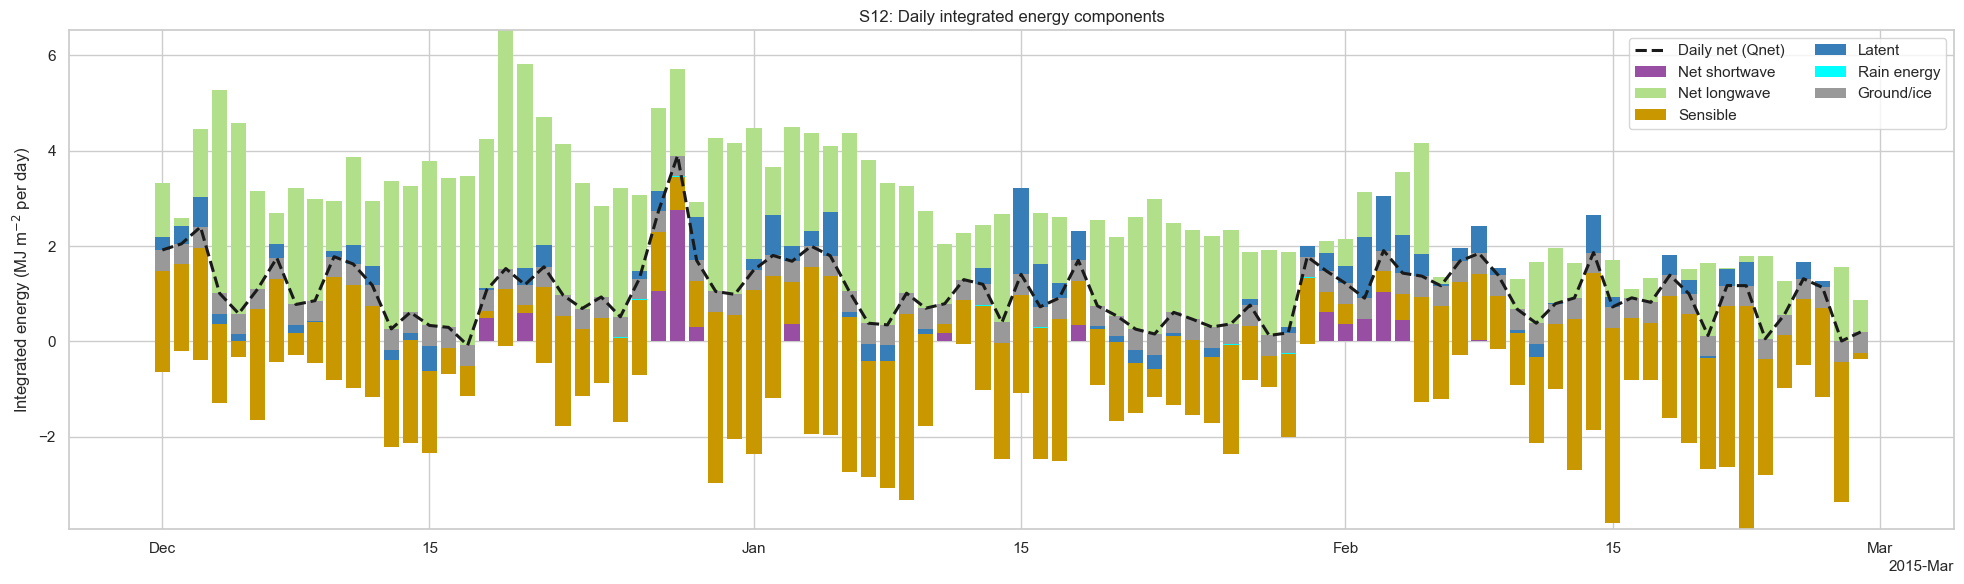

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    pass

from snowpat import pysmet as smet

# ================== USER CONFIG ==================
SCENARIO_FILES = {
    "S12": Path("S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.smet"),
    "S38"  : Path("S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.smet"),
    "S56"  : Path("S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.smet"),
    "S114"  : Path("S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.smet"),
}

# Set a date window or leave as None to show all
DATE_START = "2014-12-01"  
DATE_END   = "2015-02-28"   

# Plot options
SHOW_CUMULATIVE = True      # overlay cumulative net on right axis
FIGWIDTH_PER_DAY = 0.22     # controls figure width scaling for long periods

Lf = 334000.0  # J kg^-1 (latent heat of fusion)

# component order & colors
DESC = {
    "Qw_MJ": "Net shortwave",
    "LWR_net_MJ": "Net longwave",
    "Qs_MJ": "Sensible",
    "Ql_MJ": "Latent",
    "Qr_MJ": "Rain energy",
    "Qg_MJ": "Ground/ice",
}
COMP_ORDER = ["Qw_MJ","LWR_net_MJ","Qs_MJ","Ql_MJ","Qr_MJ","Qg_MJ"]
COMP_COLORS = {
    "Qw_MJ":       "#984ea3",  # purple → Net shortwave
    "LWR_net_MJ":  "#b2df8a",  # cyan → Net longwave
    "Qs_MJ":       "#c99700",  # golden yellow → Sensible
    "Ql_MJ":       "#377eb8",  # blue → Latent
    "Qr_MJ":       "#00ffff",  # pale green → Rain energy
    "Qg_MJ":       "#999999",  # grey → Ground/ice
}

# ---------- I/O + preparation ----------
def load_smet_to_df(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Not found: {path.resolve()}")
    obj = smet.read(str(path))
    df = pd.DataFrame(obj.data).copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    return df

def prepare_fields(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    if "Qw" not in d and {"ISWR","RSWR"}.issubset(d.columns):
        d["Qw"] = d["ISWR"] - d["RSWR"]
    if "LWR_net" not in d and {"ILWR","OLWR"}.issubset(d.columns):
        d["LWR_net"] = d["ILWR"] - d["OLWR"]

    for col in ["Qw","LWR_net","Qs","Ql","Qr","Qg"]:
        if col not in d:
            d[col] = np.nan

    d["Qnet"] = d[["Qw","LWR_net","Qs","Ql","Qr","Qg"]].sum(axis=1)

    dt = d["timestamp"].diff().dt.total_seconds()
    if len(dt) > 1:
        dt.iloc[0] = dt.iloc[1]
    d["dt_s"] = dt

    d["day"] = d["timestamp"].dt.floor("D")

    if "meltFreezeEnergySnow" not in d:
        d["meltFreezeEnergySnow"] = np.nan

    return d

# ---------- Aggregation (DAILY) ----------
def aggregate_energy_daily(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    mean_flux = d.groupby("day")[["Qw","LWR_net","Qs","Ql","Qr","Qg","Qnet"]].mean()

    def integ_MJ(col):
        return (d[col] * d["dt_s"]).groupby(d["day"]).sum() / 1e6

    E = {
        "Qw_MJ":       integ_MJ("Qw"),
        "LWR_net_MJ":  integ_MJ("LWR_net"),
        "Qs_MJ":       integ_MJ("Qs"),
        "Ql_MJ":       integ_MJ("Ql"),
        "Qr_MJ":       integ_MJ("Qr"),
        "Qg_MJ":       integ_MJ("Qg"),
        "Qnet_MJ":     integ_MJ("Qnet"),
    }

    if d["meltFreezeEnergySnow"].notna().any():
        E_melt     = (d["meltFreezeEnergySnow"].clip(lower=0)  * d["dt_s"]).groupby(d["day"]).sum() / 1e6
        E_refreeze = (-d["meltFreezeEnergySnow"].clip(upper=0) * d["dt_s"]).groupby(d["day"]).sum() / 1e6
        melt_mm, refreeze_mm = (E_melt * 1e6)/Lf, (E_refreeze * 1e6)/Lf
    else:
        idx = E["Qnet_MJ"].index
        E_melt     = pd.Series(0.0, index=idx)
        E_refreeze = pd.Series(0.0, index=idx)
        melt_mm    = pd.Series(0.0, index=idx)
        refreeze_mm= pd.Series(0.0, index=idx)

    daily = pd.concat(
        {
            "mean_Wm2": mean_flux,
            "E_MJm2": pd.DataFrame({**E, "Melt_MJ": E_melt, "Refreeze_MJ": E_refreeze}),
            "phase_mm": pd.DataFrame({"Melt_mm": melt_mm, "Refreeze_mm": refreeze_mm}),
        },
        axis=1,
    )
    daily.index.name = "day"
    return daily

# ---------- Build panel ----------
def build_panel(scenario_files: dict) -> pd.DataFrame:
    daily = {}
    for scen, path in scenario_files.items():
        df_raw = load_smet_to_df(path)
        df_prep = prepare_fields(df_raw)
        daily[scen] = aggregate_energy_daily(df_prep)
    panel = pd.concat(daily, names=["scenario","day"])
    return panel

# ---------- Subset by date ----------
def subset_panel(panel: pd.DataFrame, start: str | None, end: str | None) -> pd.DataFrame:
    if start is None and end is None:
        return panel
    idx_day = panel.index.get_level_values("day")
    if start is not None:
        start = pd.to_datetime(start)
    if end is not None:
        end = pd.to_datetime(end)
    mask = pd.Series(True, index=panel.index)
    if start is not None:
        mask &= (idx_day >= start)
    if end is not None:
        mask &= (idx_day <= end)
    return panel.loc[mask]

# ---------- Plot: daily stacked components + net overlays ----------
def plot_daily_integrated_components(panel: pd.DataFrame,
                                     savepath_prefix: str | None = None) -> None:
    for scen in panel.index.get_level_values(0).unique():
        sub = panel.loc[scen, "E_MJm2"][COMP_ORDER + ["Qnet_MJ"]].copy().sort_index()
        days = sub.index

        fig_w = max(12, len(days) * FIGWIDTH_PER_DAY)
        fig, ax = plt.subplots(figsize=(fig_w, 6))

        # Use real datetime x-coordinates
        x = mdates.date2num(days)
        width = 0.8  # bar width (days)

        # --- Stacked component bars ---
        bottom = np.zeros(len(sub))
        for comp in COMP_ORDER:
            ax.bar(x, sub[comp].values, width=width, bottom=bottom,
           label=DESC[comp], color=COMP_COLORS[comp], alpha=1, edgecolor="none")
            bottom += sub[comp].values

        # --- Overlay daily net (Qnet) ---
        ax.plot(days, sub["Qnet_MJ"].values,
            color="k", linewidth=2.2, linestyle = '--', label="Daily net (Qnet)", zorder=5)

        # Labels & title
        ax.set_ylabel("Integrated energy (MJ m$^{-2}$ per day)")
        ax.set_title(f"{scen}: Daily integrated energy components")

        # Date axis
        ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=12))
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
        plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

        # Legend
        ax.legend(loc="upper right", ncol=2, frameon=True)

        
        plt.grid(True)
        plt.tight_layout()
        if savepath_prefix:
            fig.savefig(f"{savepath_prefix}_{scen}.png", dpi=300, bbox_inches="tight")
        plt.show()

# ================== RUN ==================
if __name__ == "__main__":
    panel = build_panel(SCENARIO_FILES)
    panel = subset_panel(panel, DATE_START, DATE_END)
    plot_daily_integrated_components(panel)

# Energy-only diagnostics across warming scenarios (SNOWPACK)
## Three vertical subplots (3,1): one per scenario, stacked bars (+/- separated) + Qnet overlay.

The following fields do not conform to the SMET standard: ['Qs', 'Ql', 'Qg', 'Qg0', 'Qr', 'dIntEnergySnow', 'meltFreezeEnergySnow', 'ColdContentSnow', 'LWR_net', 'Qw', 'pAlbedo', 'mAlbedo', 'ISWR_h', 'ISWR_dir', 'ISWR_diff', 'TSS_mod', 'TSS_meas', 'T_bottom', 'VW_drift', 'MS_Snow', 'HS_mod', 'HS_meas', 'hoar_size', 'wind_trans24', 'HN3', 'HN6', 'HN12', 'HN24', 'HN72_24', 'HNW24', 'ski_pen', 'SWE', 'MS_Water', 'MS_Water_Soil', 'MS_Ice_Soil', 'MS_Wind', 'MS_Rain', 'MS_SN_Runoff', 'MS_Surface_Mass_Flux', 'MS_Soil_Runoff', 'MS_Sublimation', 'MS_Evap', 'TS0', 'TS1', 'TS2', 'TS3', 'TS4', 'Sclass1', 'Sclass2', 'zSd', 'Sd', 'zSn', 'Sn', 'zSs', 'Ss', 'zS4', 'S4', 'zS5', 'S5', 'Total_thickness', 'Ice_thickness', 'Snow_thickness', 'Snow_thickness_wrt_reference', 'Freeboard', 'Sea_level', 'Bulk_salinity', 'Avg_bulk_salinity', 'Avg_brine_salinity', 'Bottom_salinity_flux', 'Top_salinity_flux', 'Total_Flooding_Bucket']
Unknown metadata: ['plot_unit', 'plot_description', 'plot_color']
The following fi

/var/folders/lz/yyrs81c124xcy_bryhwfgn680000gn/T/ipykernel_72301/3302006839.py:81: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  if len(dt) > 1: dt.iloc[0] = dt.iloc[1]
/var/folders/lz/yyrs81c124xcy_bryhwfgn680000gn/T/ipykernel_72301/3302006839.py:81: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  if len(dt) > 1: dt.iloc[0] = dt.iloc[1]
/var/folders/lz/yyrs81c124xcy_bryhwfgn680000gn/T/ipykernel_72301/3302006839.py:81: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  if len(dt) > 1: dt.iloc[0] = dt.iloc[1]


The following fields do not conform to the SMET standard: ['Qs', 'Ql', 'Qg', 'Qg0', 'Qr', 'dIntEnergySnow', 'meltFreezeEnergySnow', 'ColdContentSnow', 'LWR_net', 'Qw', 'pAlbedo', 'mAlbedo', 'ISWR_h', 'ISWR_dir', 'ISWR_diff', 'TSS_mod', 'TSS_meas', 'T_bottom', 'VW_drift', 'MS_Snow', 'HS_mod', 'HS_meas', 'hoar_size', 'wind_trans24', 'HN3', 'HN6', 'HN12', 'HN24', 'HN72_24', 'HNW24', 'ski_pen', 'SWE', 'MS_Water', 'MS_Water_Soil', 'MS_Ice_Soil', 'MS_Wind', 'MS_Rain', 'MS_SN_Runoff', 'MS_Surface_Mass_Flux', 'MS_Soil_Runoff', 'MS_Sublimation', 'MS_Evap', 'TS0', 'TS1', 'TS2', 'TS3', 'TS4', 'Sclass1', 'Sclass2', 'zSd', 'Sd', 'zSn', 'Sn', 'zSs', 'Ss', 'zS4', 'S4', 'zS5', 'S5', 'Total_thickness', 'Ice_thickness', 'Snow_thickness', 'Snow_thickness_wrt_reference', 'Freeboard', 'Sea_level', 'Bulk_salinity', 'Avg_bulk_salinity', 'Avg_brine_salinity', 'Bottom_salinity_flux', 'Top_salinity_flux', 'Total_Flooding_Bucket']
Unknown metadata: ['plot_unit', 'plot_description', 'plot_color']


/var/folders/lz/yyrs81c124xcy_bryhwfgn680000gn/T/ipykernel_72301/3302006839.py:81: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  if len(dt) > 1: dt.iloc[0] = dt.iloc[1]


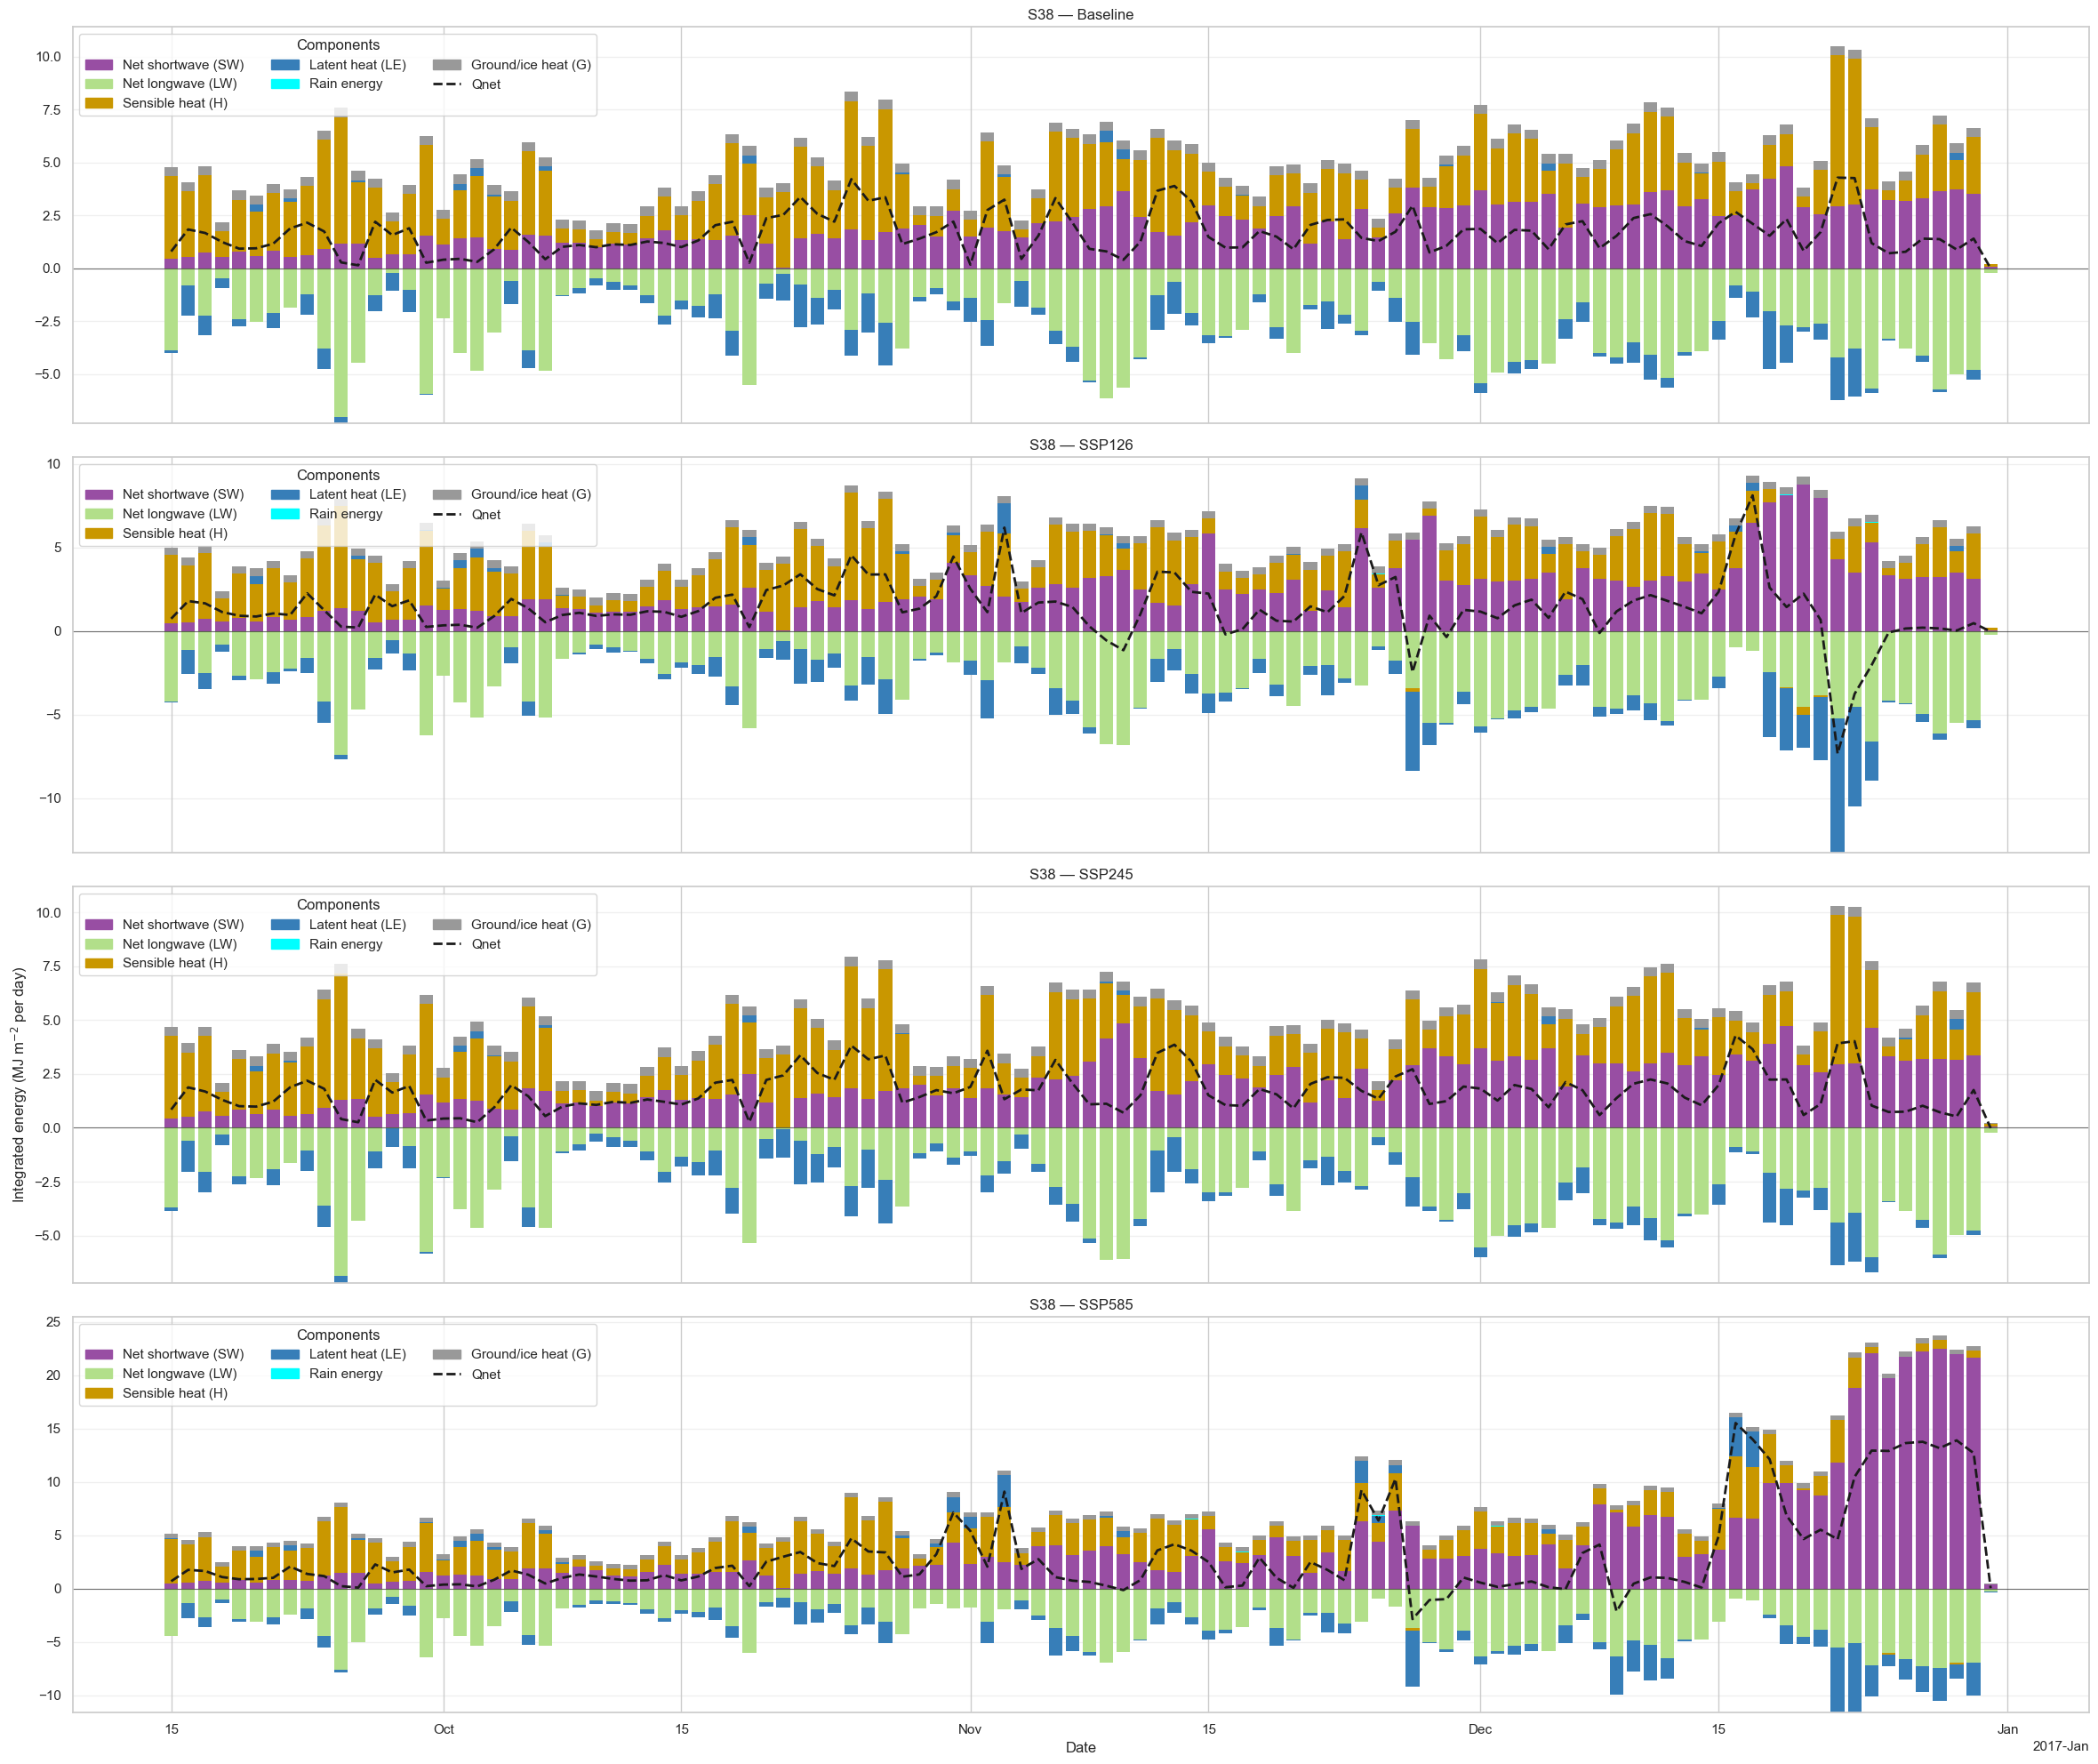

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    pass

from snowpat import pysmet as smet

# ================== USER CONFIG ==================
SCENARIO_FILES = {
    # "Baseline": Path("S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.smet"),
    # "SSP126": Path("S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.smet"),
    # "SSP245": Path("S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.smet"),
    # "SSP585": Path("S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.smet"),

    "Baseline": Path("S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.smet"),
    "SSP126": Path("S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.smet"),
    "SSP245": Path("S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.smet"),
    "SSP585": Path("S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.smet"),

    # "Baseline": Path("S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.smet"),
    # "SSP126": Path("S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.smet"),
    # "SSP245": Path("S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.smet"),
    # "SSP585": Path("S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.smet"),
}
STATION_LABEL = "S38"

# Date window (None to show all)
DATE_START = "2016-09-15"
DATE_END   = "2016-12-31"

FIGWIDTH_PER_DAY = 0.22

# Labels & colors
DESC = {
    "Qw_MJ":       "Net shortwave (SW)",
    "LWR_net_MJ":  "Net longwave (LW)",
    "Qs_MJ":       "Sensible heat (H)",
    "Ql_MJ":       "Latent heat (LE)",
    "Qr_MJ":       "Rain energy",
    "Qg_MJ":       "Ground/ice heat (G)",
    "Qnet_MJ":     "Net energy (Qnet)",
}
COMP_ORDER = ["Qw_MJ", "LWR_net_MJ", "Qs_MJ", "Ql_MJ", "Qr_MJ", "Qg_MJ"]
COMP_COLORS = {
    "Qw_MJ":       "#984ea3",  # purple → Net shortwave
    "LWR_net_MJ":  "#b2df8a",  # cyan → Net longwave
    "Qs_MJ":       "#c99700",  # golden yellow → Sensible
    "Ql_MJ":       "#377eb8",  # blue → Latent
    "Qr_MJ":       "#00ffff",  # pale green → Rain energy
    "Qg_MJ":       "#999999",  # grey → Ground/ice
}

# ---------- I/O + prep ----------
def load_smet_to_df(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Not found: {path.resolve()}")
    obj = smet.read(str(path))
    df = pd.DataFrame(obj.data).copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    return df

def prepare_fields(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    if "Qw" not in d and {"ISWR","RSWR"}.issubset(d.columns):
        d["Qw"] = d["ISWR"] - d["RSWR"]
    if "LWR_net" not in d and {"ILWR","OLWR"}.issubset(d.columns):
        d["LWR_net"] = d["ILWR"] - d["OLWR"]
    for col in ["Qw","LWR_net","Qs","Ql","Qr","Qg"]:
        if col not in d: d[col] = 0.0
        d[col] = d[col].fillna(0.0)
    d["Qnet"] = d[["Qw","LWR_net","Qs","Ql","Qr","Qg"]].sum(axis=1)
    dt = d["timestamp"].diff().dt.total_seconds()
    if len(dt) > 1: dt.iloc[0] = dt.iloc[1]
    d["dt_s"] = dt.fillna(0.0)
    d["day"] = d["timestamp"].dt.floor("D")
    # subset by date window
    if DATE_START is not None:
        d = d[d["timestamp"] >= pd.to_datetime(DATE_START)]
    if DATE_END is not None:
        d = d[d["timestamp"] <= pd.to_datetime(DATE_END)]
    return d

def aggregate_energy_daily(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    def integ_MJ(col: str) -> pd.Series:
        return (d[col] * d["dt_s"]).groupby(d["day"]).sum().div(1e6)
    E = {
        "Qw_MJ":       integ_MJ("Qw"),
        "LWR_net_MJ":  integ_MJ("LWR_net"),
        "Qs_MJ":       integ_MJ("Qs"),
        "Ql_MJ":       integ_MJ("Ql"),
        "Qr_MJ":       integ_MJ("Qr"),
        "Qg_MJ":       integ_MJ("Qg"),
        "Qnet_MJ":     integ_MJ("Qnet"),
    }
    daily = pd.concat({"E_MJm2": pd.DataFrame(E)}, axis=1)
    daily.index.name = "day"
    return daily

def build_panel(scenario_files: dict) -> pd.DataFrame:
    daily = {}
    for scen, path in scenario_files.items():
        df_raw = load_smet_to_df(path)
        df_prep = prepare_fields(df_raw)
        daily[scen] = aggregate_energy_daily(df_prep)
    panel = pd.concat(daily, names=["scenario","day"])
    return panel

# ---------- stacking helper (pos/neg separated) ----------
def _stack_pos_neg(ax, x_dates, comp_vals_dict, width=0.8):
    n = len(x_dates)
    pos_base = np.zeros(n)
    neg_base = np.zeros(n)
    for comp in COMP_ORDER:
        y = np.asarray(comp_vals_dict[comp])
        color = COMP_COLORS[comp]
        y_pos = np.where(y > 0, y, 0.0)
        ax.bar(x_dates, y_pos, width=width, bottom=pos_base, color=color, edgecolor="none")
        pos_base += y_pos
        y_neg = np.where(y < 0, y, 0.0)
        ax.bar(x_dates, y_neg, width=width, bottom=neg_base, color=color, edgecolor="none")
        neg_base += y_neg

# ---------- PLOT: 3×1 subplots (one per scenario) ----------
def plot_three_subplots(panel: pd.DataFrame, station_label: str):
    scenarios = list(panel.index.get_level_values(0).unique())
    # union of all days for consistent x-axis
    all_days = sorted(pd.to_datetime(pd.unique(panel.index.get_level_values("day"))))
    x = mdates.date2num(all_days)

    fig_w = max(12, len(all_days) * FIGWIDTH_PER_DAY)
    fig, axes = plt.subplots(4, 1, figsize=(fig_w, 20), sharex=True)
    axes = np.atleast_1d(axes)

    for ax, scen in zip(axes, scenarios):
        sub = panel.loc[scen, "E_MJm2"][COMP_ORDER + ["Qnet_MJ"]].copy()
        sub = sub.reindex(all_days).fillna(0.0)

        # Stacked bars
        comp_vals = {c: sub[c].values for c in COMP_ORDER}
        _stack_pos_neg(ax, x, comp_vals, width=0.8)

        # Qnet overlay
        ax.plot(all_days, sub["Qnet_MJ"].values, color="k", lw=2.0, ls="--", label="Qnet")

        # Cosmetics
        ax.axhline(0, color="k", lw=0.8, alpha=0.6)
        ax.set_title(f"{station_label} — {scen}")
        ax.grid(True, axis="y", alpha=0.3)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=12))
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

        # --- FIXED LEGEND ---
        comp_handles = [plt.Rectangle((0,0),1,1,color=COMP_COLORS[c]) for c in COMP_ORDER]
        comp_labels  = [DESC[c] for c in COMP_ORDER]
        qnet_handle  = plt.Line2D([0], [0], color='k', lw=2, ls='--')
        qnet_label   = "Qnet"
        ax.legend(comp_handles + [qnet_handle],
                  comp_labels + [qnet_label],
                  title="Components",
                  ncol=3, loc="upper left", frameon=True)

    axes[-1].set_xlabel("Date")
    axes[len(axes)//2].set_ylabel("Integrated energy (MJ m$^{-2}$ per day)")

    plt.tight_layout()
    plt.show()

# ================== RUN ==================
if __name__ == "__main__":
    panel = build_panel(SCENARIO_FILES)
    plot_three_subplots(panel, station_label=STATION_LABEL)

## Monthly Melt and Refreeze Calculation from SNOWPACK

**Inputs needed:**
- `meltFreezeEnergySnow` (W m⁻²):  
  - \> 0 → energy used for **melting**  
  - < 0 → energy released by **refreezing**  
- `timestamp` → to compute the time step Δt (s)  
- Latent heat of fusion:  

$$
L_f = 334{,}000 \;\; \text{J kg}^{-1}
$$

(1 kg m⁻² ≡ 1 mm water equivalent)

---

### Equations (per month)

Let  

$$
MFS(t) = \text{meltFreezeEnergySnow (W m}^{-2})
$$  

$$
\Delta t = \text{time step (s)}
$$

- **Monthly melt energy (J m⁻²):**

$$
E_{\text{melt, month}} = \sum_{\text{month}} \max\!\big(MFS(t),0\big)\,\Delta t
$$

- **Monthly refreeze energy (J m⁻²):**

$$
E_{\text{refreeze, month}} = \sum_{\text{month}} \max\!\big(-MFS(t),0\big)\,\Delta t
$$

- **Convert to mm w.e. (kg m⁻²):**

$$
\text{Melt}_{\text{mm}} = \frac{E_{\text{melt, month}}}{L_f},
\qquad
\text{Refreeze}_{\text{mm}} = \frac{E_{\text{refreeze, month}}}{L_f}
$$

---

**Notes:**
- Always compute Δt from consecutive `timestamp` values (do not assume fixed 1 h).  
- Positive melt energy corresponds to snowpack warming and phase change to liquid.  
- Refreeze energy corresponds to latent heat released back into the snowpack.



In [12]:
import pandas as pd
import numpy as np

Lf = 334000.0  # J/kg

df = df.sort_values("timestamp").copy()
dt = df["timestamp"].diff().dt.total_seconds()
if len(dt) > 1:
    dt.iloc[0] = dt.iloc[1]
df["dt_s"] = dt

# Guard if column is missing
mfs = df.get("meltFreezeEnergySnow", pd.Series(0.0, index=df.index)).fillna(0.0)

# Energy (J m^-2) per step
melt_J_step     = mfs.clip(lower=0)            * df["dt_s"]
refreeze_J_step = (-mfs).clip(lower=0)         * df["dt_s"]

df["month"] = df["timestamp"].dt.to_period("M").astype(str)

# Monthly sums
melt_J_month     = melt_J_step.groupby(df["month"]).sum()
refreeze_J_month = refreeze_J_step.groupby(df["month"]).sum()

# Convert
melt_mm_month     = melt_J_month / Lf
refreeze_mm_month = refreeze_J_month / Lf

# Optional MJ m^-2
melt_MJ_month     = melt_J_month / 1e6
refreeze_MJ_month = refreeze_J_month / 1e6

monthly = pd.DataFrame({
    "melt_mm": melt_mm_month,
    "refreeze_mm": refreeze_mm_month,
    "melt_MJm2": melt_MJ_month,
    "refreeze_MJm2": refreeze_MJ_month,
})
print(monthly)

NameError: name 'df' is not defined

SNOWPACK Rain/Latent/Melt Energy Analyzer
----------------------------------------
Reads SMET outputs for multiple buoys and scenarios, computes melt/refreeze
energies and water-equivalent amounts, and plots a *combined* time series of:

1. rain energy (candidate cols: rainEnergy, rain_energy, Q_rain, RainEnergy)

2. latent energy/flux (candidate cols: latentEnergy, latent_energy, Q_latent, latentHeatFlux)

3. snow melt/freezing energy (candidate col: meltFreezeEnergySnow)

PLUS a twin-axis overlay of cumulative melt/refreeze (mm) on the same figure.

Assumptions
-----------
1. Energy/flux columns are in W m^-2 (J s^-1 m^-2); we multiply by dt (s) to get energy per step in J m^-2.
2. "meltFreezeEnergySnow" > 0 => melting; < 0 => refreezing.
3. Timestamps are monotonically increasing per file (we sort anyway).

The following fields do not conform to the SMET standard: ['Qs', 'Ql', 'Qg', 'Qg0', 'Qr', 'dIntEnergySnow', 'meltFreezeEnergySnow', 'ColdContentSnow', 'LWR_net', 'Qw', 'pAlbedo', 'mAlbedo', 'ISWR_h', 'ISWR_dir', 'ISWR_diff', 'TSS_mod', 'TSS_meas', 'T_bottom', 'VW_drift', 'MS_Snow', 'HS_mod', 'HS_meas', 'hoar_size', 'wind_trans24', 'HN3', 'HN6', 'HN12', 'HN24', 'HN72_24', 'HNW24', 'ski_pen', 'SWE', 'MS_Water', 'MS_Water_Soil', 'MS_Ice_Soil', 'MS_Wind', 'MS_Rain', 'MS_SN_Runoff', 'MS_Surface_Mass_Flux', 'MS_Soil_Runoff', 'MS_Sublimation', 'MS_Evap', 'TS0', 'TS1', 'TS2', 'TS3', 'TS4', 'Sclass1', 'Sclass2', 'zSd', 'Sd', 'zSn', 'Sn', 'zSs', 'Ss', 'zS4', 'S4', 'zS5', 'S5', 'Total_thickness', 'Ice_thickness', 'Snow_thickness', 'Snow_thickness_wrt_reference', 'Freeboard', 'Sea_level', 'Bulk_salinity', 'Avg_bulk_salinity', 'Avg_brine_salinity', 'Bottom_salinity_flux', 'Top_salinity_flux', 'Total_Flooding_Bucket']
Unknown metadata: ['plot_unit', 'plot_description', 'plot_color']


/var/folders/lz/yyrs81c124xcy_bryhwfgn680000gn/T/ipykernel_72301/1125422160.py:95: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt.iloc[0] = dt.iloc[1]


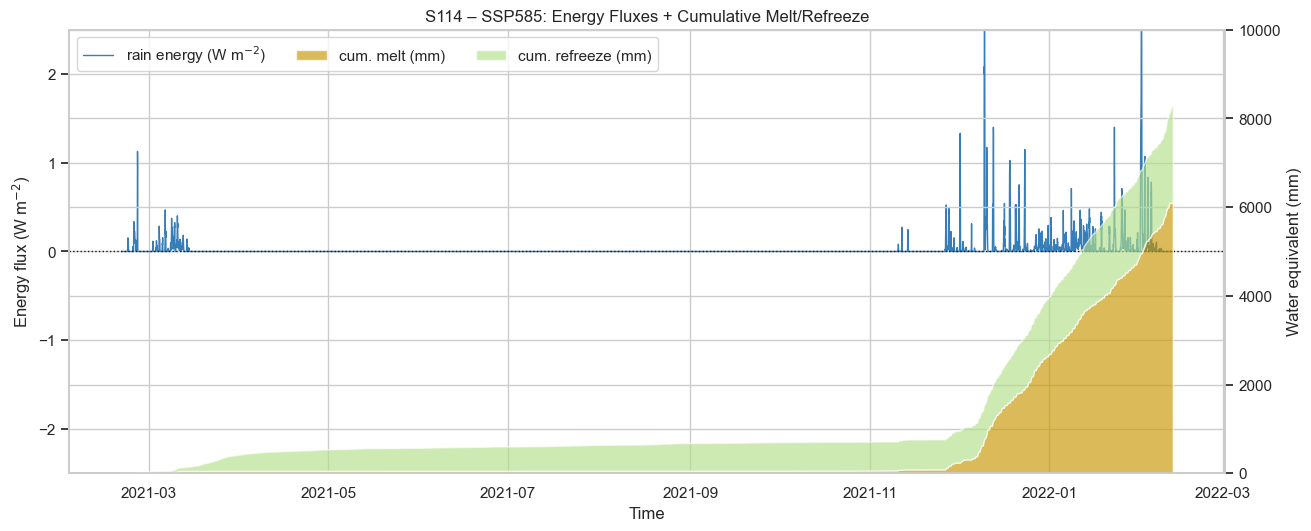

In [13]:
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import seaborn as sns
sns.set_theme(style="whitegrid")

THEME = {
    1: "#984ea3",  # purple
    2: "#00ffff",  # cyan
    3: "#c99700",  # gold
    4: "#377eb8",  # blue
    5: "#b2df8a",  # light green
}
sns.set_palette([THEME[i] for i in (1,2,3,4,5)])

from snowpat import pysmet as smet

Lf = 334000.0  # J kg^-1  (latent heat of fusion)
RHO_W = 1000.0  # kg m^-3  (for converting kg m^-2 to mm water equiv)

# ===================== INPUT FILES =====================
SCENARIO_FILES = {
    # "S38": {
    #     "baseline": Path("S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.smet"),
        # "SSP126":   Path("S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.smet"),
        # "SSP245":   Path("S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.smet"),
        # "SSP585":   Path("S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.smet"),
    # },
    # "S12": {
    #     "baseline": Path("S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.smet"),
    #     "SSP126":   Path("S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.smet"),
    #     "SSP245":   Path("S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.smet"),
    #     "SSP585":   Path("S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.smet"),
    # },
    # "S56": {
    #     "baseline": Path("S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.smet"),
    #     "SSP126":   Path("S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.smet"),
    #     "SSP245":   Path("S56_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.smet"),
    #     "SSP585":   Path("S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.smet"),
    # },
    "S114": {
        # "baseline": Path("S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.smet"),
        # "SSP126":   Path("S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.smet"),
        # "SSP245":   Path("S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.smet"),
        "SSP585":   Path("S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.smet"),
    },
}
# =======================================================

# ---------- helpers ----------
def load_smet_to_df(path: Path) -> pd.DataFrame:
    """Load a SMET file to DataFrame with a parsed and sorted 'timestamp' column."""
    if not path.exists():
        raise FileNotFoundError(f"SMET not found: {path.resolve()}")
    if smet is None:
        raise ImportError("snowpat.pysmet not available. Install or replace the reader.")

    obj = smet.read(str(path))
    df = pd.DataFrame(obj.data)
    # normalize column names (case-insensitive, no spaces)
    df.columns = [c.strip() for c in df.columns]

    # timestamp
    if "timestamp" not in df.columns:
        # some SMETs use 'time' or similar
        for alt in ("time", "date", "datetime"):
            if alt in df.columns:
                df = df.rename(columns={alt: "timestamp"})
                break
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    return df

def pick_col(df: pd.DataFrame, candidates: list[str], default: float | int = 0.0) -> pd.Series:
    """Return the first available column from candidates; else a default-filled Series."""
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        # direct match
        if cand in df.columns:
            return df[cand].astype(float).fillna(0.0)
        # case-insensitive match
        if cand.lower() in lower_map:
            return df[lower_map[cand.lower()]].astype(float).fillna(0.0)
    return pd.Series(default, index=df.index, dtype=float)

def add_dt(df: pd.DataFrame) -> pd.DataFrame:
    """Compute dt (s) per row with a forward-fill of the first element."""
    out = df.copy()
    dt = out["timestamp"].diff().dt.total_seconds()
    if len(dt) > 1:
        dt.iloc[0] = dt.iloc[1]
    else:
        dt = pd.Series(0.0, index=out.index)
    out["dt_s"] = dt.fillna(0.0)
    return out

def compute_melt_freeze(df: pd.DataFrame,
                        mfs_candidates: list[str] | None = None,
                        ) -> pd.DataFrame:
    """
    Given a DataFrame with flux columns (W m^-2), compute per-step energies (J m^-2)
    and melt/refreeze water-equivalent (mm).
    """
    if mfs_candidates is None:
        mfs_candidates = ["meltFreezeEnergySnow", "snow_melt_freeze_energy", "melt_freeze_energy_snow"]

    out = add_dt(df)

    mfs = pick_col(out, mfs_candidates, default=0.0)

    # J m^-2 per step from W m^-2 * s
    melt_J_step     = mfs.clip(lower=0.0) * out["dt_s"]
    refreeze_J_step = (-mfs).clip(lower=0.0) * out["dt_s"]

    out["melt_J_step"] = melt_J_step
    out["refreeze_J_step"] = refreeze_J_step

    # cumulative (J m^-2)
    out["melt_J_cum"] = melt_J_step.cumsum()
    out["refreeze_J_cum"] = refreeze_J_step.cumsum()

    # Convert to water-equivalent mm (1 kg m^-2 = 1 mm)
    # energy / Lf = kg m^-2; multiply by 1 (mm per kg m^-2)
    out["melt_mm_step"] = melt_J_step / Lf
    out["refreeze_mm_step"] = refreeze_J_step / Lf
    out["melt_mm_cum"] = out["melt_mm_step"].cumsum()
    out["refreeze_mm_cum"] = out["refreeze_mm_step"].cumsum()

    # month key
    out["month"] = out["timestamp"].dt.to_period("M").astype(str)

    return out

def monthly_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Monthly sums of melt/refreeze in both J m^-2 and mm."""
    grp = df.groupby("month")
    melt_J     = grp["melt_J_step"].sum()
    refreeze_J = grp["refreeze_J_step"].sum()
    melt_mm     = melt_J / Lf
    refreeze_mm = refreeze_J / Lf

    out = pd.DataFrame({
        "melt_Jm2": melt_J,
        "refreeze_Jm2": refreeze_J,
        "melt_mm": melt_mm,
        "refreeze_mm": refreeze_mm,
        "melt_MJm2": melt_J / 1e6,
        "refreeze_MJm2": refreeze_J / 1e6,
    })
    return out

def monthly_rain_energy(df_flux: pd.DataFrame) -> pd.DataFrame:
    """
    Monthly cumulative rain energy from flux (W m^-2) -> energy (J m^-2).
    Uses common column aliases for rain energy; adjust if needed.
    """
    # Ensure dt_s exists
    df = add_dt(df_flux)

    # Try common rain-energy/rain-flux column names (including 'Qr')
    q_rain = pick_col(df, ["rainEnergy", "rain_energy", "Q_rain", "RainEnergy", "Qr"], default=0.0)

    # Convert to J m^-2 per step
    # If your rain energy is guaranteed >= 0, this clip is redundant but harmless
    rain_J_step = q_rain.clip(lower=0.0) * df["dt_s"]

    # Month key
    month = df["timestamp"].dt.to_period("M").astype(str)
    grp = pd.DataFrame({"month": month, "rain_J_step": rain_J_step}).groupby("month", as_index=True)

    rain_Jm2 = grp["rain_J_step"].sum()

    out = pd.DataFrame({
        "rain_Jm2": rain_Jm2,
        "rain_MJm2": rain_Jm2 / 1e6,
    })
    return out

def plot_combined_timeseries(df_flux: pd.DataFrame,
                           df_calc: pd.DataFrame,
                           station: str,
                           scenario: str) -> None:
    """
    Show a combined plot:
      - Primary y-axis (left): energy fluxes (W m^-2) for rain, latent, and melt/freezing
      - Secondary y-axis (right): cumulative melt/refreeze (mm)
    """
    # Pick flux columns on the raw flux dataframe
    q_rain  = pick_col(df_flux, ["Qr"], default=0.0)
    q_lat   = pick_col(df_flux, ["Ql"], default=0.0)
    q_mfs   = pick_col(df_flux, ["meltFreezeEnergySnow"], default=0.0)
    q_sens  = pick_col(df_flux, ["Qs"], default=0.0)

    t = df_flux["timestamp"]

    fig, ax1 = plt.subplots(figsize=(13, 5.2), constrained_layout=True)

    # Energy fluxes on left axis
    ax1.plot(t, q_rain, label="rain energy (W m$^{-2}$)", color=THEME[4] , lw=1)
    # ax1.plot(t, q_lat,  label="latent energy (W m$^{-2}$)")
    # ax1.plot(t, q_mfs,  label="snow melt/freezing (W m$^{-2}$)")
    # ax1.plot(t, q_sens,  label="Sensible energy (W m$^{-2}$)", color="k")
    ax1.axhline(0.0, lw=1, ls=":", color="k")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Energy flux (W m$^{-2}$)")
    ax1.set_ylim(-2.5,2.5)

    # # Cumulative melt/refreeze on right axis
    # ax2 = ax1.twinx()
    # ax2.plot(df_calc["timestamp"], df_calc["melt_mm_cum"], linestyle="-", label="cum. melt (mm)")
    # ax2.plot(df_calc["timestamp"], df_calc["refreeze_mm_cum"], linestyle="-", label="cum. refreeze (mm)")
    # ax2.set_ylabel("Water equivalent (mm)")
    # ax2.set_ylim(0,5000)

    # Cumulative melt/refreeze on right axis — STACKED AREA instead of lines
    ax2 = ax1.twinx()
    t2 = df_calc["timestamp"]
    melt = df_calc["melt_mm_cum"].to_numpy()
    refz = df_calc["refreeze_mm_cum"].to_numpy()

    # Cumulative melt/refreeze on right axis — STACKED AREA
    ax2.stackplot(
        t2,
        melt,
        refz,
        labels=["cum. melt (mm)", "cum. refreeze (mm)"],
        colors=[THEME[3], THEME[5]],  # melt=purple, refreeze=cyan (adjust if you prefer)
        alpha=0.65
        )
    ax2.set_ylabel("Water equivalent (mm)")
    ax2.set_ylim(0, 10000)

    # Build a combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, ncol=3, frameon=True, loc="upper left")

    plt.title(f"{station} – {scenario}: Energy Fluxes + Cumulative Melt/Refreeze")
    plt.show()

def process_all(mapping: dict[str, dict[str, Path]]) -> None:
    for station, scen_map in mapping.items():
        for scen, path in scen_map.items():
            try:
                df_raw = load_smet_to_df(path)
                df_calc = compute_melt_freeze(df_raw)

                # Combined plot (no saving)
                plot_combined_timeseries(df_raw, df_calc, station, scen)

                # # Monthly summary printed to stdout
                # monthly = monthly_summary(df_calc)
                # print(f"\n==== Monthly melt/refreeze for {station} – {scen} ====")
                # print(monthly.to_string(float_format=lambda x: f"{x:.3f}"))
                
                # # NEW: Monthly cumulative rain energy
                # rain_monthly = monthly_rain_energy(df_raw)
                # print(f"\n==== Monthly rain energy for {station} – {scen} ====")
                # print(rain_monthly.to_string(float_format=lambda x: f"{x:.3f}"))

            except Exception as e:
                print(f"✖ {station}-{scen}: {e}")

if __name__ == "__main__":
    process_all(SCENARIO_FILES)